<a href="https://colab.research.google.com/github/itinasharma/MachineLearning/blob/main/Visualise_the_rank_1_collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

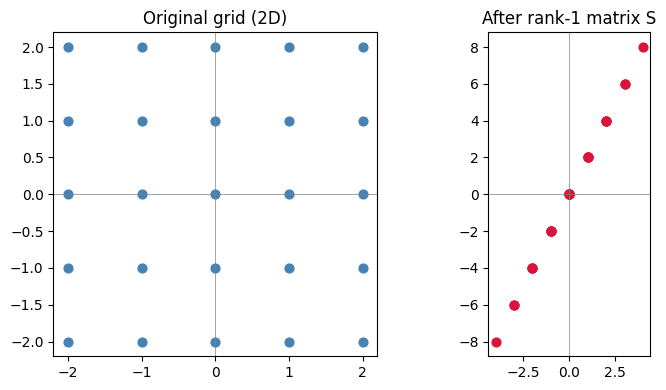

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Build a 5x5 grid of 2D points
xs = np.linspace(-2, 2, 5)
ys = np.linspace(-2, 2, 5)
grid = np.array([(x, y) for x in xs for y in ys])   # shape (25, 2)

# Rank-1 matrix: second row is 2x the first
S = np.array([[1., 1.],
              [2., 2.]])

transformed = grid @ S.T   # shape (25, 2)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].scatter(grid[:, 0], grid[:, 1], c="steelblue", s=40)
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].axvline(0, color="gray", lw=0.5)
axes[0].set_title("Original grid (2D)")
axes[0].set_aspect("equal")

axes[1].scatter(transformed[:, 0], transformed[:, 1], c="crimson", s=40)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].axvline(0, color="gray", lw=0.5)
axes[1].set_title("After rank-1 matrix S")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

Try it out:

**Experiment 1:** Change S to [[1,0],[0,1]] (identity). All points stay put — rank 2, nothing collapses.

**Experiment 2:** Change S to [[1,0.01],[2,0.02]]. The second row is nearly 2× the first. Watch the points almost-but-not-quite collapse to a line. Now run np.linalg.matrix_rank(S) and compare to the visual.

**Experiment 3:** Try a random 512×64 matrix: W = np.random.randn(64,512), then np.linalg.matrix_rank(W). How often is it full rank? (Almost always — random matrices are almost surely full rank.)



In [4]:
S = np.array([[1., 0.],
              [0., 1.]])
print(np.linalg.matrix_rank(S))

2


Rank 2 means both independent directions survive.

In [5]:
S = np.array([[1., 0.01],
              [2., 0.021]])
print("Rank:", np.linalg.matrix_rank(S))

Rank: 2


When directions become nearly dependent, information becomes nearly redundant.

In [6]:
W = np.random.randn(64, 512)

print("Shape:", W.shape)
print("Rank:", np.linalg.matrix_rank(W))

Shape: (64, 512)
Rank: 64


A 512→64 layer already loses dimensions, but a full-rank matrix preserves as much structure as possible inside those 64 dimensions.